# 2.0 — H3: Industry Concentration

## Hypothesis

Delaware's active business licenses are concentrated in industry sectors that are **structurally underrepresented in modern value chains** — i.e., the SME base is dominated by consumer-facing services, retail, and contracting, with very thin representation in B2B manufacturing, wholesale, and specialized professional services that anchor institutions (DuPont, Christiana Care, Dover AFB, state government) typically procure from.

## Why this matters

If confirmed, the case's "weak integration into corporate and institutional supply chains" framing has a structural root: the businesses don't exist in the right industries to begin with, regardless of any procurement-matchmaking program. The solution then needs to address industry composition (what businesses we help start), not just access (helping existing businesses get into procurement).

If rejected, the value-chain story becomes a pure access problem — which is a different and arguably easier intervention.

## Decision rule (pre-committed)

I will classify the 84 Business Activity values into 7 broad sectors: Consumer Services, Retail & Food, Construction, Wholesale & Distribution, Manufacturing, Professional Services, and Real Estate & Other.

**Confirmed:** Consumer-facing categories (Consumer Services + Retail & Food + Construction) exceed 70% of licenses, AND the value-chain-aligned categories (Manufacturing + Wholesale & Distribution + Professional Services) total under 15%.

**Partial:** Consumer-facing share is 60–70% OR value-chain share is 15–25%.

**Rejected:** Consumer-facing share is below 60% AND value-chain share is above 25%.

## Surprise log
- _(append findings here as we go)_

In [2]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

from src import config
import pandas as pd
import matplotlib.pyplot as plt

# Load cleaned dataset
df = pd.read_parquet(config.DATA_INTERIM / "licenses_de_clean.parquet")

print(f"Loaded: {len(df):,} licenses across {df['Business Activity'].nunique()} activity types")
df["Business Activity"].value_counts().head(10)

Matplotlib is building the font cache; this may take a moment.


Loaded: 46,216 licenses across 80 activity types


Business Activity
GENERAL SERVICES                     19109
RESIDENT CONTRACTOR                   7527
RETAILER  GENERAL                     5280
COMMERICAL LESSOR                     2403
RETAILER  RESTAURANT                  2193
WHOLESALER                            1621
DRAYPERSON OR MOVER                    879
CIGARETTE/TOBACCO PRODUCTS SELLER      862
MOTOR VEHICLE DEALER                   562
MANUFACTURER                           497
Name: count, dtype: int64

- 2025-04-18: After applying the canonical DE filter, NON-RESIDENT CONTRACTOR 
  drops out of the top categories and WHOLESALER drops 46% (2,994 → 1,621). 
  Implication: Delaware's wholesale/distribution and contractor activity is 
  heavily supplied by out-of-state businesses. This is itself a value-chain 
  finding — DE SMEs are not the dominant suppliers in these categories even 
  within DE.

In [6]:
# --- Sector mapping (extended to cover all 80 DE activity types) ---------
SECTOR_MAP = {
    # ----- Consumer Services ------------------------------------------------
    "GENERAL SERVICES": "Consumer Services",
    "BARBER SHOP": "Consumer Services",
    "HAIR BRAIDING SHOP": "Consumer Services",
    "BARBER OR COSMETOLOGIST": "Consumer Services",
    "MASSAGE ESTABLISHMENT": "Consumer Services",
    "MASSAGE TECHNICIAN": "Consumer Services",
    "TANNING FACILITY": "Consumer Services",
    "ELECTROLOGIST": "Consumer Services",
    "PHOTOGRAPHER": "Consumer Services",
    "PHOTOGRAPHER  TRANSIENT": "Consumer Services",
    "DRAYPERSON OR MOVER": "Consumer Services",
    "TAXICAB OR BUS OPERATOR": "Consumer Services",
    "TRANSIENT RETAILER": "Consumer Services",
    "AMUSEMENT CONDUCTOR": "Consumer Services",
    "AMUSEMENT CONDUCTOR / OWNER": "Consumer Services",
    "OUTDOOR MUSIC FESTIVAL PROMOTER": "Consumer Services",
    "CIRCUSES & CARNIVALS": "Consumer Services",
    "FINANCE OR SMALL LOAN AGENCY": "Consumer Services",
    "PAWNBROKER": "Consumer Services",
    "MERCANTILE AGENCY OR COLLECTIONS AGENCY": "Consumer Services",
    "PRIVATE DETECTIVE/SECURITY AGENCY": "Consumer Services",
    "PRIVATE INVESTIGATIVE & SECURITY ENTITY": "Consumer Services",
    "ADVERTISING AGENCY": "Consumer Services",
    "AUCTIONEER": "Consumer Services",
    "RESIDENT AUCTIONEER": "Consumer Services",
    "NON-RESIDENT AUCTIONEER": "Consumer Services",
    "JUNK DEALER": "Consumer Services",
    "SCRAP METAL PROCESSOR": "Consumer Services",
    "POOL & BILLIARD ROOM": "Consumer Services",
    "BOWLING ALLEY": "Consumer Services",
    "PUBLIC POOL": "Consumer Services",
    "TATTOO PARLOR / BODY PIERCING": "Consumer Services",
    "DIRECT CARE WORKER": "Consumer Services",
    "TRAVEL AGENCY": "Consumer Services",
    "HOTEL": "Consumer Services",
    "MOTEL": "Consumer Services",
    "TOURIST HOME": "Consumer Services",
    "ACCOMMODATIONS INTERMEDIARY": "Consumer Services",
    "RECREATION VEHICLE PARK": "Consumer Services",
    "SECURITY ALARM BUSINESS": "Consumer Services",
    "SECURITY GUARD/PRIVATE DETECTIVE": "Consumer Services",
    "BAIL BONDSMAN": "Consumer Services",
    "BAIL ENFORCEMENT AGENT": "Consumer Services",
    "SHOWPERSON": "Consumer Services",

    # ----- Retail & Food ----------------------------------------------------
    "RETAILER  GENERAL": "Retail & Food",
    "RETAILER  RESTAURANT": "Retail & Food",
    "RETAILER  PETROLEUM": "Retail & Food",
    "RETAILER  ALCOHOL - OFF PREMISE": "Retail & Food",
    "RETAILER  ALCOHOL - ON PREMISE": "Retail & Food",
    "RETAILER  FARM MACHINERY": "Retail & Food",
    "RETAILER MUSICAL INSTRUMENTS DEVICES": "Retail & Food",
    "RETAILER  TRANSIENT": "Retail & Food",
    "RETAILER  TRANSIENT 10-DAY": "Retail & Food",
    "RETAILER  TRANSIENT NURSERY": "Retail & Food",
    "MOTOR VEHICLE DEALER": "Retail & Food",
    "USED CAR DEALER": "Retail & Food",
    "CIGARETTE/TOBACCO PRODUCTS SELLER": "Retail & Food",
    "TOBACCO RETAILER": "Retail & Food",
    "TOBACCO REMOTE SELLER": "Retail & Food",
    "DIRECT SELLER OF TOBACCO/VAPOR PRODUCTS": "Retail & Food",
    "VAPOR PRODUCTS DEALER": "Retail & Food",
    "GROCERY SUPERMARKET RETAILER": "Retail & Food",
    "FOOD PROCESSOR DAIRY": "Retail & Food",
    "FOOD PROCESSOR EGGS": "Retail & Food",
    "FOOD ESTABLISHMENT - MOBILE": "Retail & Food",
    "FOOD ESTABLISHMENT - SEASONAL": "Retail & Food",
    "FARM MACHINERY RETAILER": "Retail & Food",
    "VENDING MACHINE OPERATOR": "Retail & Food",
    "VENDING MACHINE DECALS": "Retail & Food",
    "AMUSEMENT MACHINE DECALS": "Retail & Food",
    "CIGARETTE VENDING MACHINES": "Retail & Food",
    "CATALOG/MAIL ORDER WHOLESALER": "Retail & Food",  # mail-order = consumer-facing

    # ----- Construction -----------------------------------------------------
    "RESIDENT CONTRACTOR": "Construction",
    "NON-RESIDENT CONTRACTOR": "Construction",
    "CONTRACTOR/SUBCONTRACTOR": "Construction",
    "DEMOLITION CONTRACTOR": "Construction",
    "CONSTRUCTION MANAGER": "Construction",
    "CONSTRUCTION TRANSPORTATION CONTRACTOR": "Construction",
    "NON-RESIDENT CONST TRANSPORT CONTRACTOR": "Construction",

    # ----- Wholesale & Distribution ----------------------------------------
    "WHOLESALER": "Wholesale & Distribution",
    "WHOLESALE FOOD PROCESSOR": "Wholesale & Distribution",
    "FOOD PROCESSOR WHOLESALER": "Wholesale & Distribution",
    "WHOLESALE PETROLEUM PRODUCT": "Wholesale & Distribution",
    "WHOLESALER  PETROLEUM PRODUCT": "Wholesale & Distribution",
    "PETROLEUM PRODUCT DISTRIBUTOR": "Wholesale & Distribution",
    "DISTRIBUTOR": "Wholesale & Distribution",
    "ALCOHOL WHOLESALER": "Wholesale & Distribution",
    "TOBACCO PRODUCTS WHOLESALER": "Wholesale & Distribution",
    "VAPOR WHOLESALER": "Wholesale & Distribution",
    "CIGARETTE WHOLESALER AND AFFIXING AGENT": "Wholesale & Distribution",
    "PHARMACEUTICAL WHOLESALER": "Wholesale & Distribution",
    "PHARMACEUTICAL DISTRIBUTION WHOLESALER": "Wholesale & Distribution",
    "NURSERY WHOLESALER": "Wholesale & Distribution",
    "COMMERCIAL FEED DEALER": "Wholesale & Distribution",
    "TRANSPORTATION AGENT": "Wholesale & Distribution",

    # ----- Manufacturing ---------------------------------------------------
    "MANUFACTURER": "Manufacturing",
    "MANUFACTURER REPRESENTATIVE": "Manufacturing",
    "MANUFACTURER AGENT OR REPRESENTATIVE": "Manufacturing",
    "DAIRY PRODUCT MANUFACTURER": "Manufacturing",
    "FOOD PROCESSOR": "Manufacturing",
    "ALCOHOL MANUFACTURER": "Manufacturing",
    "MANUFACTURER  CLEAN ENERGY": "Manufacturing",
    "MANUFACTURER  AUTO": "Manufacturing",
    "STEAM GAS ELECTRIC": "Manufacturing",  # utility/industrial production

    # ----- Professional Services -------------------------------------------
    "PROFESSIONAL ENGINEER": "Professional Services",
    "ARCHITECT": "Professional Services",
    "REAL ESTATE BROKER": "Professional Services",
    "REAL ESTATE APPRAISER": "Professional Services",
    "BROKER": "Professional Services",
    "SALES REPRESENTATIVE": "Professional Services",
    "BIDDING ONLY": "Professional Services",  # bidder for govt/anchor contracts

    # ----- Real Estate & Other ---------------------------------------------
    "COMMERICAL LESSOR": "Real Estate & Other",
    "REAL ESTATE DEVELOPER": "Real Estate & Other",
    "NON-RESIDENT REAL ESTATE DEVELOPERS": "Real Estate & Other",
    "MOBILE HOME PARK OPERATOR": "Real Estate & Other",
    "TRAILER PARK OPERATOR": "Real Estate & Other",
    "PARKING LOT OR GARAGE OPERATOR": "Real Estate & Other",
    "LESSOR OF TANGIBLE PERSONAL PROPERTY": "Real Estate & Other",
    "LESSOR-MOTOR VEHICLES": "Real Estate & Other",
    "LESSEE - TANGIBLE PROPERTY LICENSE": "Real Estate & Other",
    "TRADE NAME ONLY REGISTRANT": "Real Estate & Other",
    "FARM LABOR AGENCY": "Real Estate & Other",
    "EMPLOYMENT AGENCY": "Real Estate & Other",
    "FARM PRODUCTS AUCTIONEER": "Real Estate & Other",
}

# Apply mapping
df["sector"] = df["Business Activity"].map(SECTOR_MAP).fillna("Unmapped")

# Diagnostic
unmapped = df[df["sector"] == "Unmapped"]["Business Activity"].value_counts()
print(f"Unmapped activities: {len(unmapped)} types covering {unmapped.sum():,} rows ({unmapped.sum()/len(df):.1%} of total)")
if len(unmapped) > 0:
    print()
    print("Still unmapped:")
    print(unmapped)
else:
    print("All activities mapped.")
print()
print("Rows per sector:")
print(df["sector"].value_counts())

Unmapped activities: 0 types covering 0 rows (0.0% of total)
All activities mapped.

Rows per sector:
sector
Consumer Services           21417
Retail & Food               10131
Construction                 8078
Real Estate & Other          3365
Wholesale & Distribution     1932
Professional Services         692
Manufacturing                 601
Name: count, dtype: int64


- 2025-04-18: H3 CONFIRMED with wide margin. Consumer-facing categories total 
  85.7% of DE licensed businesses (Consumer Services 46.3%, Retail & Food 21.9%, 
  Construction 17.5%). Value-chain-aligned categories total 7.0% (Manufacturing 
  1.3%, Wholesale 4.2%, Professional Services 1.5%). 
  
  Most striking: Delaware has only 601 active manufacturers and 692 professional 
  service firms (engineers/architects/brokers). The SME base is structurally 
  not in the kinds of industries anchor institutions buy from.
  
  Strategic implication: Reorder case framing. H3 (industry composition) 
  becomes the headline finding; H1 (geographic capital access) becomes 
  supporting evidence for why the structural pattern persists.

Saved: /Users/renzo/Documents/DSU_UN/reports/figures/h3_sector_concentration.png


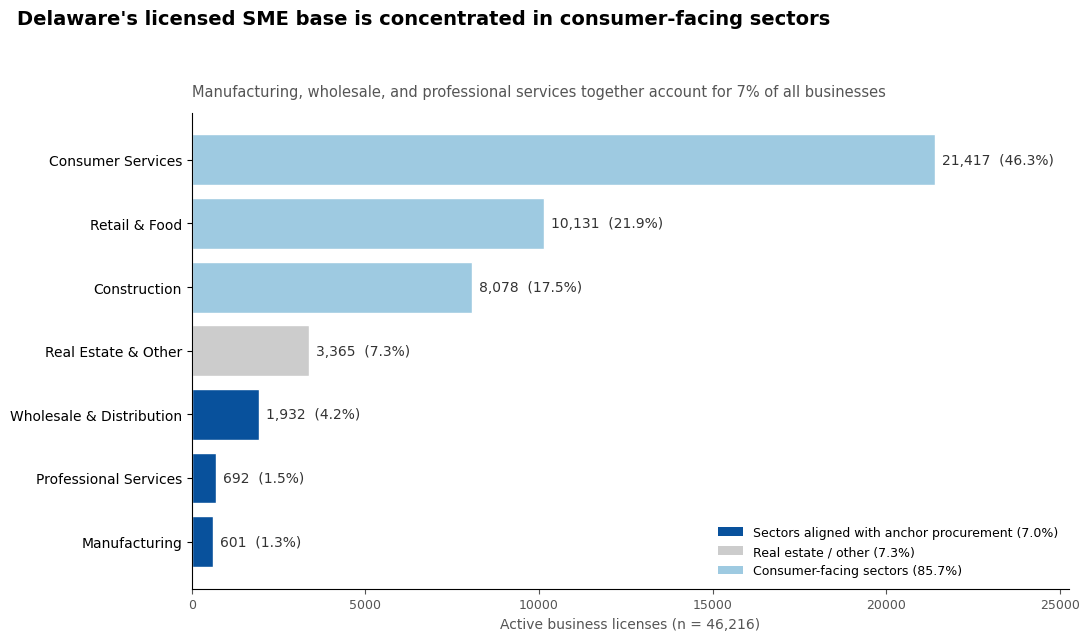

In [10]:
# --- Cell 4: Headline visualization for H3 (revised palette + typography)
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Compute sector shares
sector_counts = df["sector"].value_counts()
sector_share = (sector_counts / len(df) * 100).round(1)

# Bucket assignment for color coding
bucket = {
    "Consumer Services": "Consumer-facing",
    "Retail & Food": "Consumer-facing",
    "Construction": "Consumer-facing",
    "Real Estate & Other": "Neutral",
    "Wholesale & Distribution": "Value-chain",
    "Professional Services": "Value-chain",
    "Manufacturing": "Value-chain",
}

# Sequential blue palette — descriptive, not evaluative
colors = {
    "Consumer-facing": "#9ecae1",   # light blue
    "Neutral":         "#cccccc",   # neutral gray
    "Value-chain":     "#08519c",   # deep blue
}

# Order sectors by count, descending
order = sector_counts.index.tolist()
bar_colors = [colors[bucket[s]] for s in order]

# Plot
fig, ax = plt.subplots(figsize=(11, 6.5))
bars = ax.barh(order, sector_counts.values, color=bar_colors, edgecolor="white")
ax.invert_yaxis()

# Annotate with counts and percentages
for bar, count, pct in zip(bars, sector_counts.values, sector_share.values):
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
            f"{count:,}  ({pct}%)",
            va="center", fontsize=10, color="#333333")

# Title hierarchy: bold finding, lighter sub-line with breathing room
fig.suptitle(
    "Delaware's licensed SME base is concentrated in consumer-facing sectors",
    fontsize=14, fontweight="bold", x=0.02, y=0.98, ha="left",
)
ax.set_title(
    "Manufacturing, wholesale, and professional services together account for 7% of all businesses",
    fontsize=10.5, color="#555555", loc="left", pad=12,
)

ax.set_xlabel("Active business licenses (n = 46,216)", fontsize=10, color="#555555")
ax.set_xlim(0, sector_counts.max() * 1.18)
ax.tick_params(axis="y", labelsize=10)
ax.tick_params(axis="x", labelsize=9, colors="#555555")

# Legend — describe what the colors mean, not whether they're good/bad
legend_elements = [
    Patch(facecolor="#08519c", label="Sectors aligned with anchor procurement (7.0%)"),
    Patch(facecolor="#cccccc", label="Real estate / other (7.3%)"),
    Patch(facecolor="#9ecae1", label="Consumer-facing sectors (85.7%)"),
]
ax.legend(handles=legend_elements, loc="lower right", frameon=False, fontsize=9)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.94])  # leaves room for suptitle

# Save
output_path = config.FIGURES / "h3_sector_concentration.png"
plt.savefig(output_path, dpi=200, bbox_inches="tight")
print(f"Saved: {output_path}")
plt.show()

## H3 Summary: Industry Concentration

**Verdict: CONFIRMED with wide margin.**

### Result against pre-committed decision rule

| Bucket | Threshold | Actual | Pass? |
|---|---|---|---|
| Consumer-facing share | > 70% | **85.7%** | ✅ |
| Value-chain-aligned share | < 15% | **7.0%** | ✅ |

### Sector breakdown

| Sector | Licenses | Share |
|---|---|---|
| Consumer Services | 21,417 | 46.3% |
| Retail & Food | 10,131 | 21.9% |
| Construction | 8,078 | 17.5% |
| Real Estate & Other | 3,365 | 7.3% |
| Wholesale & Distribution | 1,932 | 4.2% |
| Professional Services | 692 | 1.5% |
| Manufacturing | 601 | 1.3% |
| **Total** | **46,216** | **100%** |

### Headline findings

1. **Delaware has only 601 active manufacturers** — about 1.3% of the licensed business base. Anchor institutions (DuPont, Chemours, Incyte, Mountaire, Perdue, Christiana Care, Dover AFB) collectively spend billions annually on manufactured inputs, against an extremely thin local supplier pool.

2. **Professional services are similarly thin.** Just 692 licensed engineers, architects, brokers, and sales representatives statewide — the intermediary professionals who would help SMEs prepare for and navigate anchor procurement processes.

3. **Construction is the largest non-consumer sector** at 17.5% (8,078 businesses). This is a meaningful local capacity, but most contractors operate as direct-to-consumer or small-job providers rather than as integrated suppliers in larger value chains.

4. **Out-of-state concentration in distribution.** When we applied the canonical DE filter, WHOLESALER counts dropped 46% (2,994 → 1,621), and NON-RESIDENT CONTRACTOR exited the top categories entirely. Implication: the wholesale and distribution activity inside Delaware is heavily supplied by non-DE businesses — a finding that reinforces the value-chain gap.

### Strategic implication for the case

The "weak integration into corporate and institutional supply chains" framing in the prompt has a **structural** root, not just an access root. The businesses that anchor procurement typically buys from — manufacturers, B2B wholesalers, specialized professional services — barely exist in Delaware's licensed SME base.

This means the case's solution should address **two layers**:

- **Short-term (access):** procurement matchmaking, supplier-readiness programs, certifications for the ~3,200 existing value-chain-aligned businesses
- **Long-term (composition):** industry-development incentives that grow the manufacturing, professional-services, and B2B distribution base — addressing the structural shortage rather than just optimizing access for the few firms that already qualify

### Recommended case framing change

H3 should be the **headline finding** of the analysis, not a supporting point. H1 (geographic capital access) and H2 (county disparity) become evidence for *why* the structural pattern persists across geography and time.

### Methodology notes

- Unit of analysis: license rows (n = 46,216), per pre-committed Option A in `0.1-rl-data-validation.ipynb`
- Source: `data/interim/licenses_de_clean.parquet`
- Sector mapping: 80 Delaware Business Activity values mapped to 7 sectors via `SECTOR_MAP` (cell 3); 0 unmapped
- Three sector-assignment judgment calls noted in cell 3 comments (STEAM GAS ELECTRIC, CATALOG/MAIL ORDER WHOLESALER, TRANSPORTATION AGENT) — none are large enough to flip the verdict
- Robustness check available: re-run with deduplicated business-name unit (Option B) if any downstream finding becomes knife-edge

### Output

- Figure: `reports/figures/h3_sector_concentration.png`
- Cleaned data unchanged; this notebook is read-only against the parquet